# 📊 Análisis EDA y Visualización — Calidad del Aire en Beijing
**Proyecto de Análisis de Contaminación Atmosférica · Parte B Python**

---

## 📋 Índice

1. [Carga y Descripción del Dataset](#1-carga-y-descripcion)
2. [Comparativa de Contaminantes por Estación](#2-comparativa-estaciones)
3. [Estacionalidad Mensual de PM2.5](#3-estacionalidad-mensual)
4. [Análisis Horario: Hora Punta](#4-analisis-horario)
5. [Suavizado: Rolling vs EWMA](#5-suavizado)
6. [Heatmap Hora × Día de la Semana](#6-heatmap-hora-dia)
7. [Análisis del Viento: Dirección y Dispersión](#7-viento)
8. [Tendencia Anual y Evolución Temporal](#8-tendencia-anual)
9. [Modelado Exploratorio: Clasificación y Nowcasting](#9-modelado)
10. [Matriz de Correlación](#10-correlacion)
11. [🏁 Decálogo de Recomendaciones](#11-decalogo)

---
> **Fuentes de referencia:** OMS Air Quality Guidelines (2021) · EPA AQI Breakpoints · Normativa China GB 3095-2012

---
<a id='1-carga-y-descripcion'></a>
## 1. Carga y Descripción del Dataset

Los datos provienen del dataset **Beijing Multi-Site Air-Quality (UCI)**, preprocesados en el notebook `01_limpieza.ipynb`. Contienen mediciones horarias de contaminantes y variables meteorológicas en múltiples estaciones de Beijing entre 2013 y 2017.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import numpy as np
from scipy import stats

# Estilo global consistente
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 120

# RUTA ABSOLUTA (Tu link directo)
ruta_csv = r"C:\Users\Antonio\Desktop\Python\beijing-air-quality\data\processed\beijing_unified_cleaned.csv"

# Para evitar líos de permisos, creamos la carpeta de reportes 
# en la misma carpeta donde está el CSV
ruta_reports = r"C:\Users\Antonio\Desktop\Python\beijing-air-quality\data\processed\reports"
os.makedirs(ruta_reports, exist_ok=True)

# Carga del dataset
df = pd.read_csv(ruta_csv, index_col='date', parse_dates=True)

print(f"✅ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"📅 Periodo: {df.index.min().date()} → {df.index.max().date()}")
print(f"📍 Estaciones: {df['station'].nunique()} → {sorted(df['station'].unique())}")

df.head()

✅ Dataset cargado: 420,768 filas × 13 columnas
📅 Periodo: 2013-03-01 → 2017-02-28
📍 Estaciones: 12 → ['Aotizhongxin', 'Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']


,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
date,,,,,,,,,,,,,
2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


### Diccionario de Variables

| Columna | Nombre Completo | Categoría | Descripción | Importancia |
| :--- | :--- | :--- | :--- | :--- |
| **PM2.5** | Partículas Finas (<2.5 µm) | Contaminante | Entran en el torrente sanguíneo | ⭐ Indicador principal de riesgo |
| **PM10** | Partículas Gruesas (<10 µm) | Contaminante | Polvo, polen, moho | Indica tormentas de arena o construcción |
| **SO2** | Dióxido de Azufre | Contaminante | Gas de combustión de carbón/fósiles | Indicador de calefacción e industria |
| **NO2** | Dióxido de Nitrógeno | Contaminante | Gas irritante por combustión motores | Indicador de tráfico; picos en hora punta |
| **CO** | Monóxido de Carbono | Contaminante | Combustión incompleta | Alto en invierno; relacionado con PM2.5 |
| **O3** | Ozono Troposférico | Contaminante | Formado por reacción fotoquímica | Comportamiento inverso: sube en verano/mediodía |
| **TEMP** | Temperatura | Meteorología | Grados Celsius | Clave para detectar inversión térmica |
| **PRES** | Presión Atmosférica | Meteorología | hPa | Alta presión = aire estancado = esmog |
| **DEWP** | Punto de Rocío | Meteorología | Medida de humedad | Alta humedad → niebla tóxica |
| **RAIN** | Lluvia | Meteorología | Precipitación (mm) | Efecto lavado: limpia el aire |
| **wd** | Dirección del Viento | Meteorología | N, S, E, W | Norte=aire limpio; Sur=aire industrial |
| **WSPM** | Velocidad del Viento | Meteorología | m/s | Viento fuerte = dispersión |
| **station** | Estación | Metadatos | Localización del sensor | Para análisis espacial |

> **Umbral OMS (2021):** PM2.5 medio anual ≤ 5 µg/m³ · PM2.5 24h ≤ 15 µg/m³  
> **Umbral China GB 3095-2012:** PM2.5 medio anual ≤ 35 µg/m³

---
<a id='2-comparativa-estaciones'></a>
## 2. Comparativa de Contaminantes por Estación

Analizamos la distribución de PM2.5, NO2 y O3 para cada estación de monitoreo. Los boxplots permiten comparar medianas, variabilidad y valores extremos simultáneamente.

✅ Guardado: 01_comparativa_PM25.png


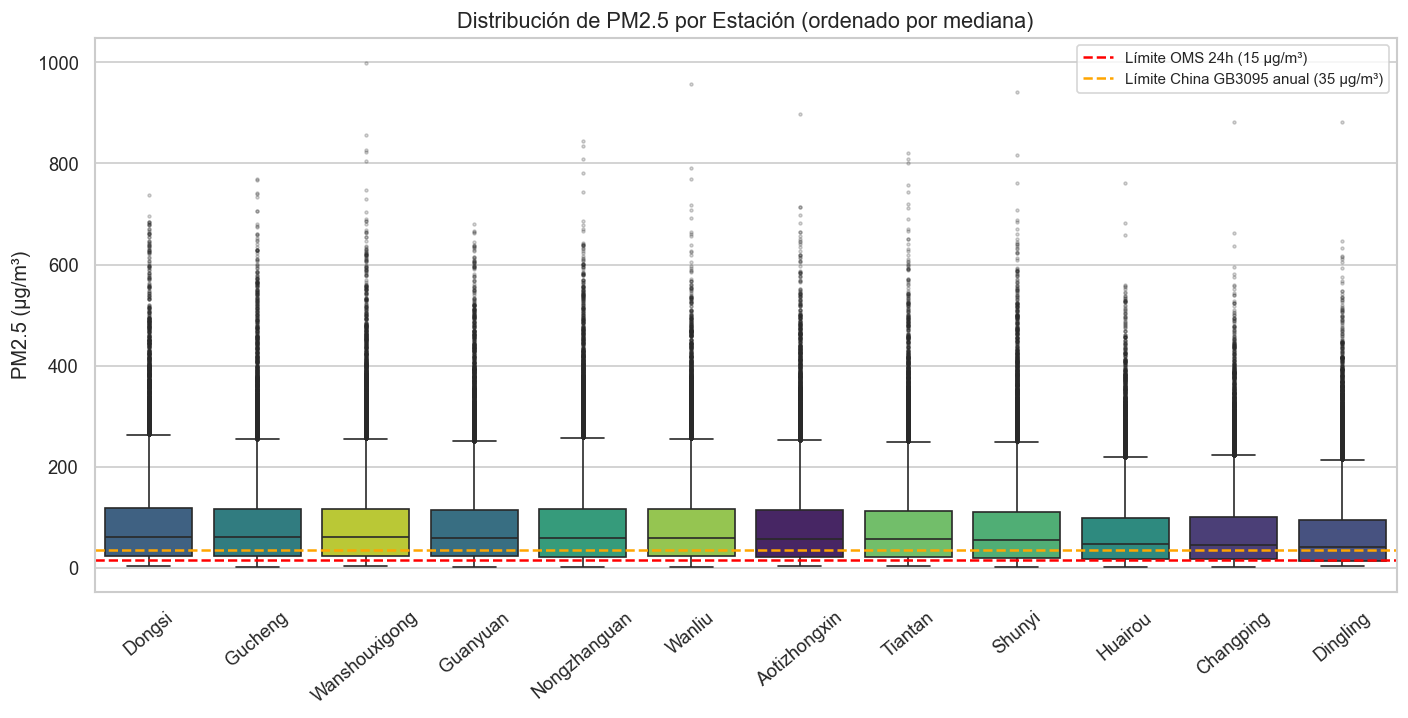

✅ Guardado: 01_comparativa_NO2.png


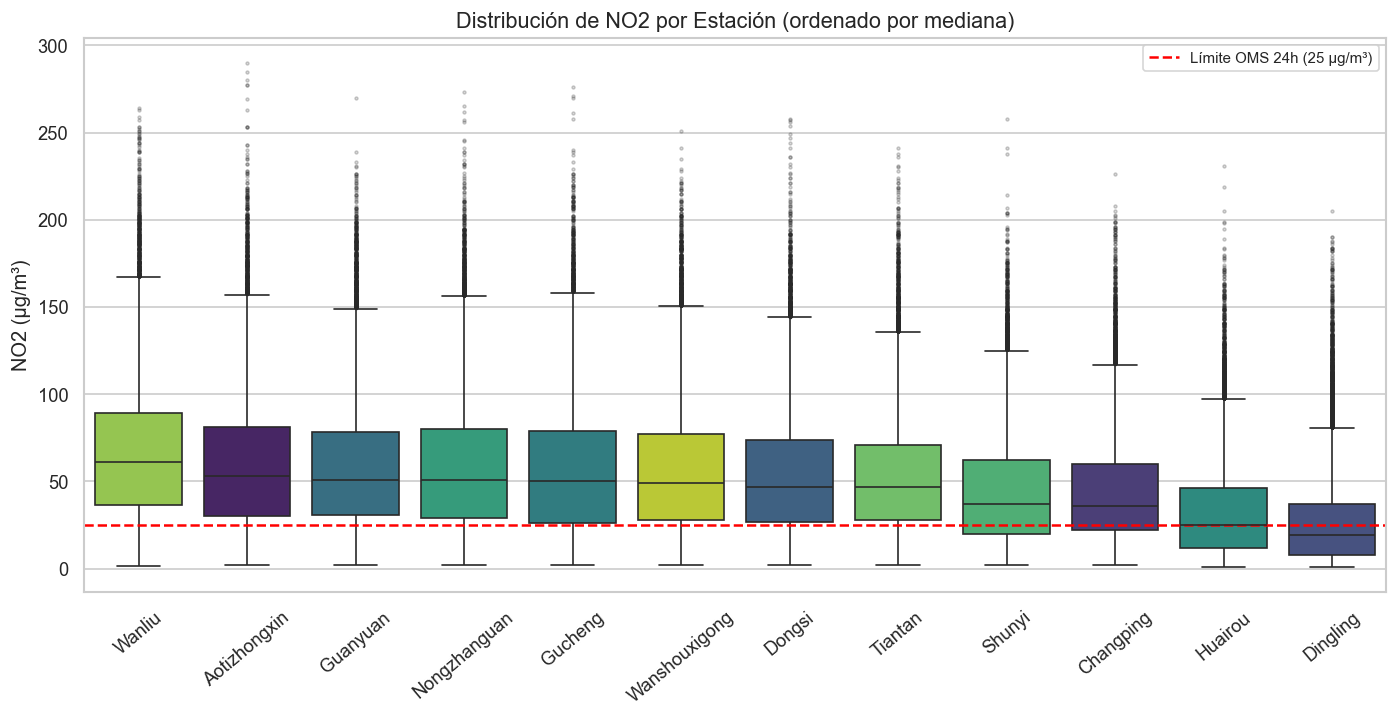

✅ Guardado: 01_comparativa_O3.png


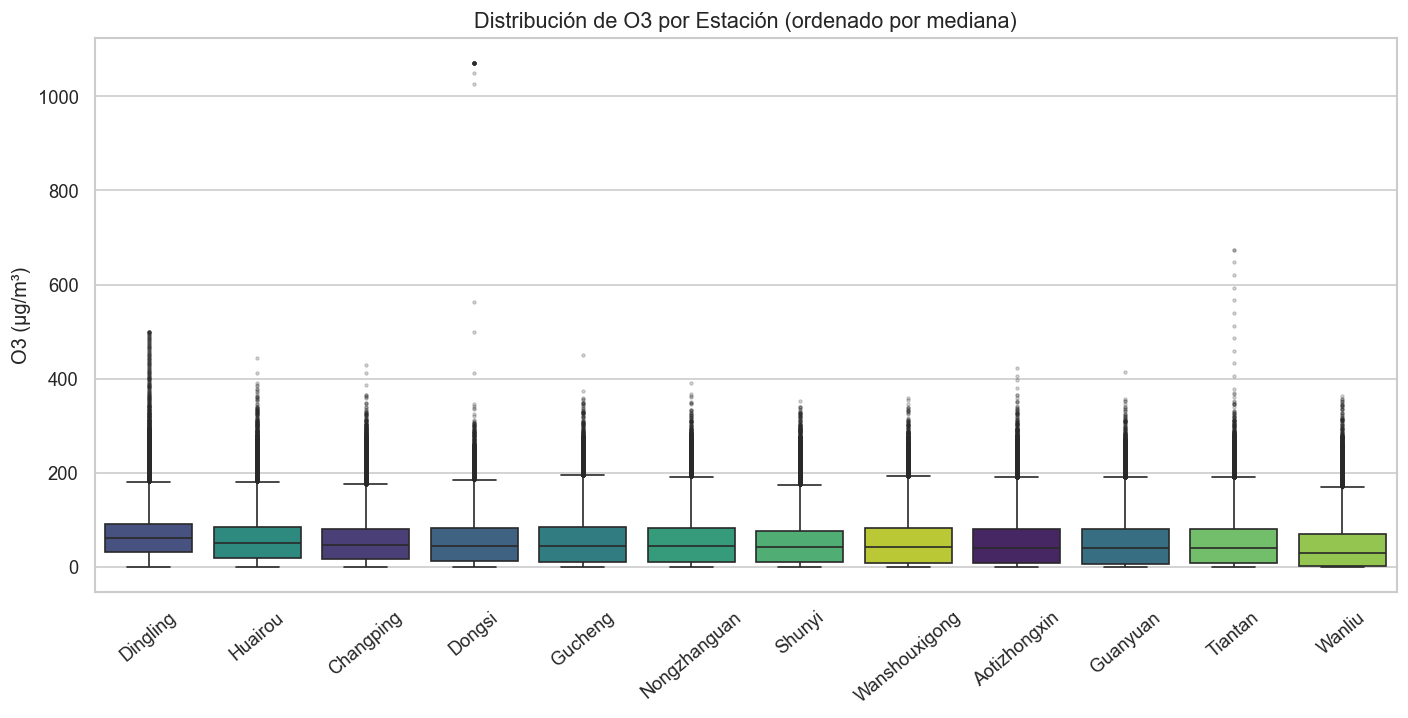

In [6]:
contaminantes = ['PM2.5', 'NO2', 'O3']
nombres = {'PM2.5': 'PM2.5 (µg/m³)', 'NO2': 'NO2 (µg/m³)', 'O3': 'O3 (µg/m³)'}

for poll in contaminantes:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    orden = df.groupby('station')[poll].median().sort_values(ascending=False).index
    
    sns.boxplot(x='station', y=poll, data=df, order=orden,
                palette='viridis', hue='station', legend=False, ax=ax,
                flierprops=dict(marker='o', markersize=1.5, alpha=0.3))
    
    # Línea de referencia OMS donde aplica
    if poll == 'PM2.5':
        ax.axhline(15, color='red', linestyle='--', linewidth=1.5,
                   label='Límite OMS 24h (15 µg/m³)')
        ax.axhline(35, color='orange', linestyle='--', linewidth=1.5,
                   label='Límite China GB3095 anual (35 µg/m³)')
        ax.legend(fontsize=9)
    elif poll == 'NO2':
        ax.axhline(25, color='red', linestyle='--', linewidth=1.5,
                   label='Límite OMS 24h (25 µg/m³)')
        ax.legend(fontsize=9)
    
    ax.set_title(f'Distribución de {poll} por Estación (ordenado por mediana)', fontsize=13)
    ax.set_ylabel(nombres[poll])
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=40)
    
    nombre_limpio = poll.replace('.', '')
    ruta = os.path.join(ruta_reports, f'01_comparativa_{nombre_limpio}.png')
    plt.savefig(ruta, bbox_inches='tight')
    print(f"✅ Guardado: 01_comparativa_{nombre_limpio}.png")
    plt.show()

### 🔍 Interpretación

**PM2.5:** Prácticamente **todas las estaciones superan sistemáticamente el límite OMS de 15 µg/m³**, lo que convierte la contaminación por partículas finas en un problema estructural de la ciudad, no puntual. Las estaciones con medianas más elevadas suelen coincidir con zonas de mayor densidad de tráfico o actividad industrial. Las colas superiores (outliers) evidencian episodios críticos de contaminación severa que pueden multiplicar por 10 el valor medio.

**NO2:** El patrón espacial refleja claramente la huella del tráfico rodado. Las diferencias entre estaciones son menores que en PM2.5, lo que sugiere que las emisiones de tráfico están distribuidas por toda la ciudad.

**O3:** Presenta el patrón inverso al NO2 (correlación negativa por titulación química): las estaciones con más tráfico tienen menos ozono porque el NO2 local lo consume. El O3 es más alto en zonas periféricas con menor tráfico directo.

> **⚠️ Nota para el Ayuntamiento:** Si el PM2.5 sube junto al NO2 → restricción de tráfico. Si sube el SO2 → foco en industria o calefacción de carbón.

---
<a id='3-estacionalidad-mensual'></a>
## 3. Estacionalidad Mensual de PM2.5

Analizamos cómo varía la media mensual de PM2.5 a lo largo del año, desglosando por estación de monitoreo para detectar patrones regionales.

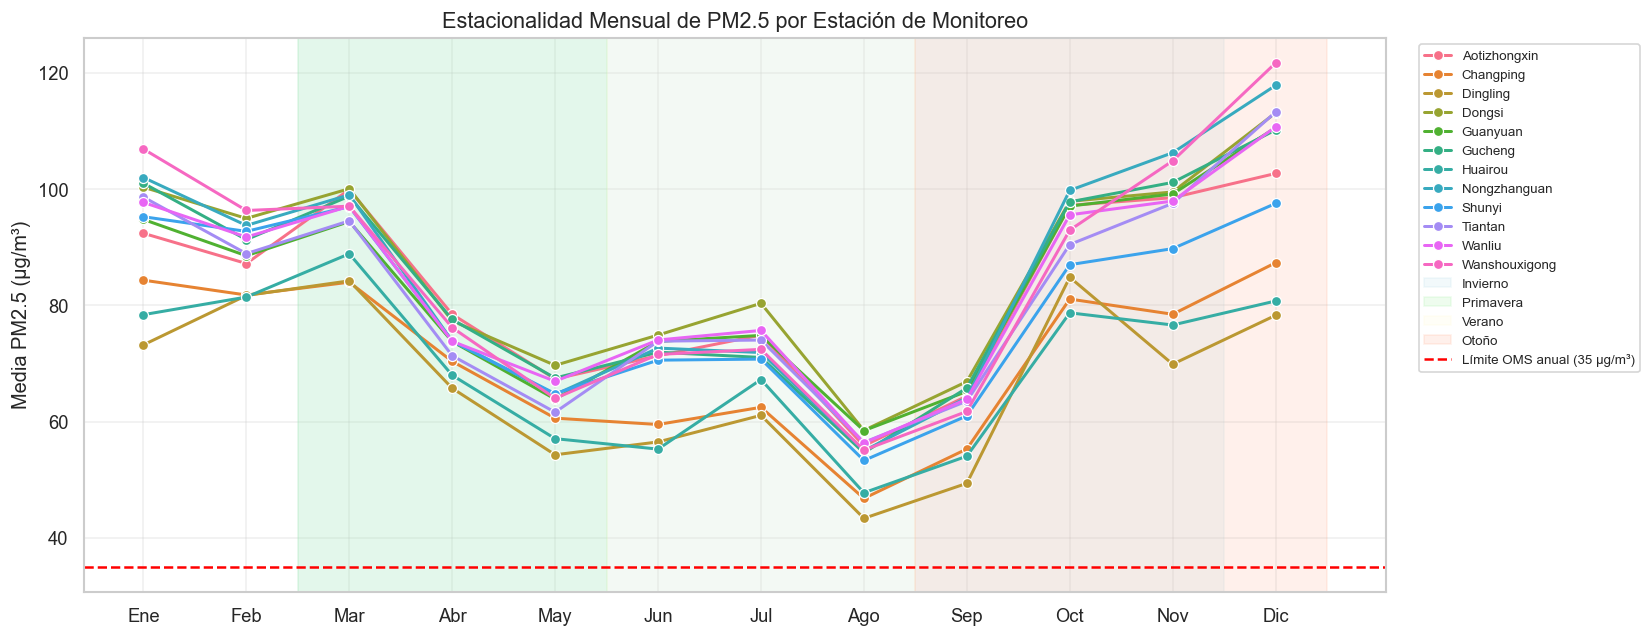

In [9]:
meses_es = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
            7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}

estacionalidad = df.groupby([df.index.month, 'station'])['PM2.5'].mean().reset_index()
estacionalidad.columns = ['month', 'station', 'avg_pm25']
estacionalidad['mes_label'] = estacionalidad['month'].map(meses_es)

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(data=estacionalidad, x='month', y='avg_pm25',
             hue='station', marker='o', ax=ax, linewidth=1.8)

# Bandas estacionales coloreadas
for inicio, fin, color, label in [(12, 3, '#add8e6', 'Invierno'), (3, 6, '#90ee90', 'Primavera'),
                                   (6, 9, '#fffacd', 'Verano'), (9, 12, '#ffa07a', 'Otoño')]:
    ax.axvspan(inicio-0.5, fin-0.5 if fin != 12 else 12.5, alpha=0.15, color=color, label=label)

ax.axhline(35, color='red', linestyle='--', linewidth=1.5, label='Límite OMS anual (35 µg/m³)')

ax.set_title('Estacionalidad Mensual de PM2.5 por Estación de Monitoreo', fontsize=13)
ax.set_ylabel('Media PM2.5 (µg/m³)')
ax.set_xlabel('')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_es.values())
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.savefig(os.path.join(ruta_reports, '02_estacionalidad_mensual.png'), bbox_inches='tight')
plt.show()

### 🔍 Interpretación

Observamos un **patrón estacional en forma de "U"**: la contaminación desciende en los meses de verano (julio-agosto) y repunta drásticamente en invierno (diciembre-enero). Este patrón es consistente en **todas las estaciones simultáneamente**, lo que confirma que la contaminación en Beijing es un **fenómeno regional estructural** y no depende de eventos aislados en puntos específicos de la ciudad.

Los **factores que explican este patrón** son:
- **Invierno:** Mayor uso de calefacción de carbón + inversiones térmicas frecuentes + menor velocidad del viento → acumulación de partículas.
- **Verano:** Mayor radiación solar activa la dispersión fotoquímica + vientos más intensos + lluvias de monzón que lavan el aire.

La **mayor divergencia entre estaciones** ocurre en invierno, indicando que ciertas zonas sufren picos mucho más agresivos que otras, probablemente por su cercanía a fuentes de calefacción o industria.

> **Referencia:** OMS Air Quality Guidelines 2021 — La exposición prolongada a PM2.5 > 35 µg/m³ (media anual) se asocia a incremento significativo de mortalidad cardiovascular y respiratoria.

---
<a id='4-analisis-horario'></a>
## 4. Análisis Horario: Patrones de Hora Punta

Estudiamos cómo varía la concentración de PM2.5 y NO2 a lo largo del día para identificar las horas de mayor riesgo.

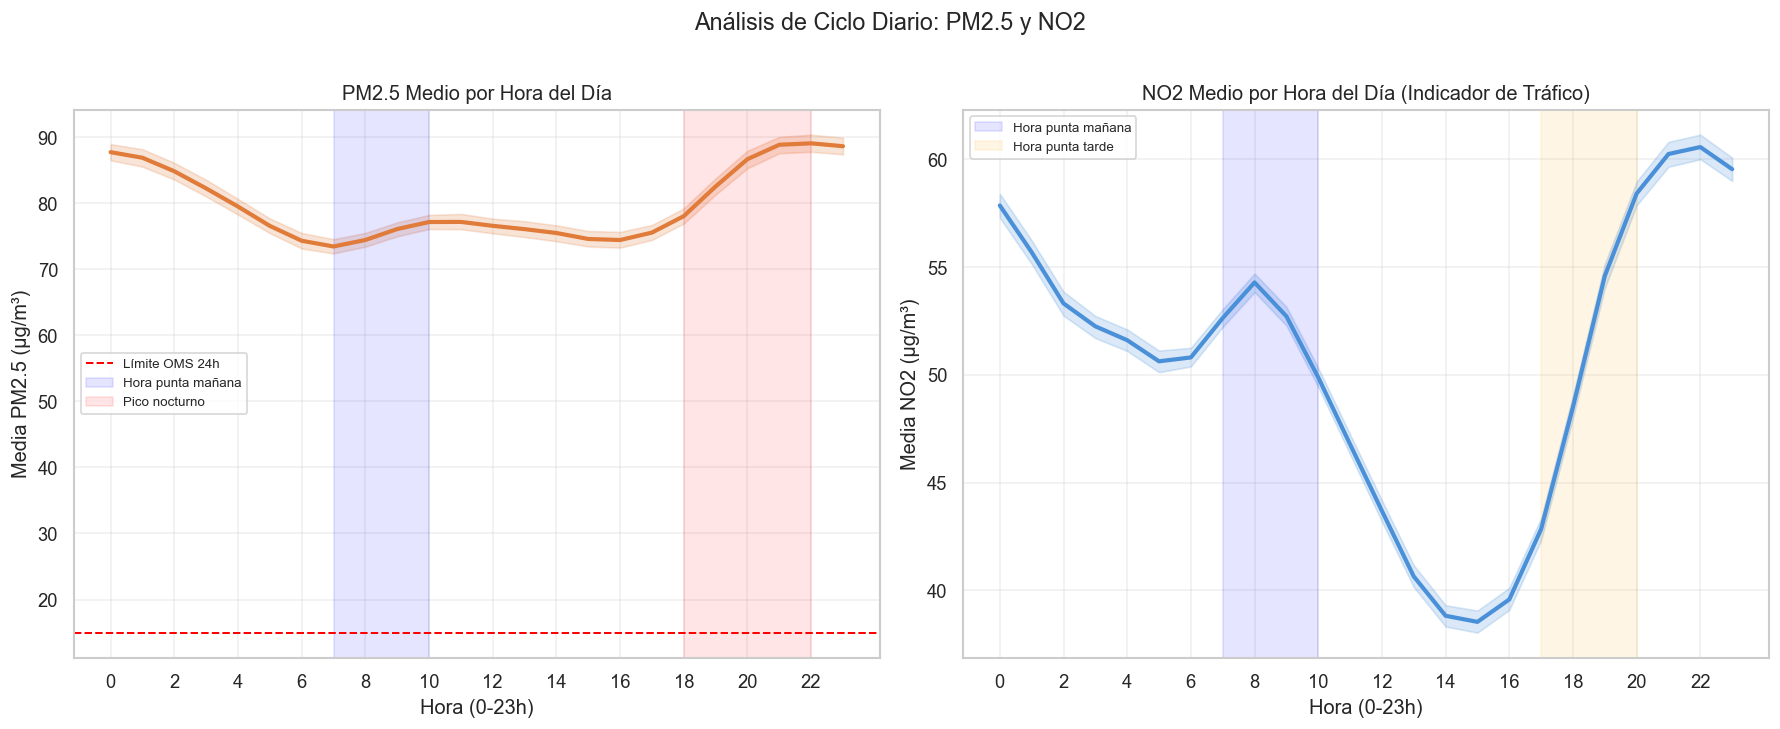

In [12]:
if 'hour' not in df.columns:
    df['hour'] = df.index.hour

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PM2.5 por hora
sns.lineplot(x='hour', y='PM2.5', data=df, estimator='mean',
             color='#e07b39', linewidth=2.5, ax=axes[0],
             errorbar=('ci', 95), err_kws={'alpha': 0.2})
axes[0].axhline(15, color='red', linestyle='--', linewidth=1.2, label='Límite OMS 24h')
axes[0].axvspan(7, 10, alpha=0.1, color='blue', label='Hora punta mañana')
axes[0].axvspan(18, 22, alpha=0.1, color='red', label='Pico nocturno')
axes[0].set_title('PM2.5 Medio por Hora del Día', fontsize=12)
axes[0].set_xlabel('Hora (0-23h)')
axes[0].set_ylabel('Media PM2.5 (µg/m³)')
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

# NO2 por hora (indicador de tráfico)
sns.lineplot(x='hour', y='NO2', data=df, estimator='mean',
             color='#4a90d9', linewidth=2.5, ax=axes[1],
             errorbar=('ci', 95), err_kws={'alpha': 0.2})
axes[1].axvspan(7, 10, alpha=0.1, color='blue', label='Hora punta mañana')
axes[1].axvspan(17, 20, alpha=0.1, color='orange', label='Hora punta tarde')
axes[1].set_title('NO2 Medio por Hora del Día (Indicador de Tráfico)', fontsize=12)
axes[1].set_xlabel('Hora (0-23h)')
axes[1].set_ylabel('Media NO2 (µg/m³)')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

plt.suptitle('Análisis de Ciclo Diario: PM2.5 y NO2', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '03_analisis_horario.png'), bbox_inches='tight')
plt.show()

### 🔍 Interpretación

El gráfico de **NO2** revela con nitidez la firma del tráfico: dos picos claramente diferenciados en hora punta de mañana (7-10h) y tarde (17-20h), patrón clásico de una gran ciudad.

El **PM2.5**, en cambio, muestra un comportamiento diferente y más preocupante: aunque hay un pequeño repunte matutino, el **verdadero pico ocurre a partir de las 18h y se extiende hasta la madrugada**. Este desacoplamiento entre NO2 (tráfico) y PM2.5 (nocturno) se explica por:

1. **Inversión térmica nocturna:** Al caer el sol el suelo se enfría, formando una capa de aire frío en la superficie que atrapa los contaminantes emitidos durante el día.
2. **Calefacción doméstica:** Se activa al llegar a casa (~18-21h), siendo una fuente directa de PM2.5.
3. **Transporte pesado:** Beijing prohíbe camiones en horas diurnas; sus emisiones se concentran en la noche.

> **Implicación práctica:** Las alertas de calidad del aire deben emitirse *antes* de las 18h para ser preventivas, no reactivas.

---
<a id='5-suavizado'></a>
## 5. Comparativa de Métodos de Suavizado: Rolling vs EWMA

Comparamos dos técnicas de suavizado de series temporales para la detección de episodios y la gestión de alertas.

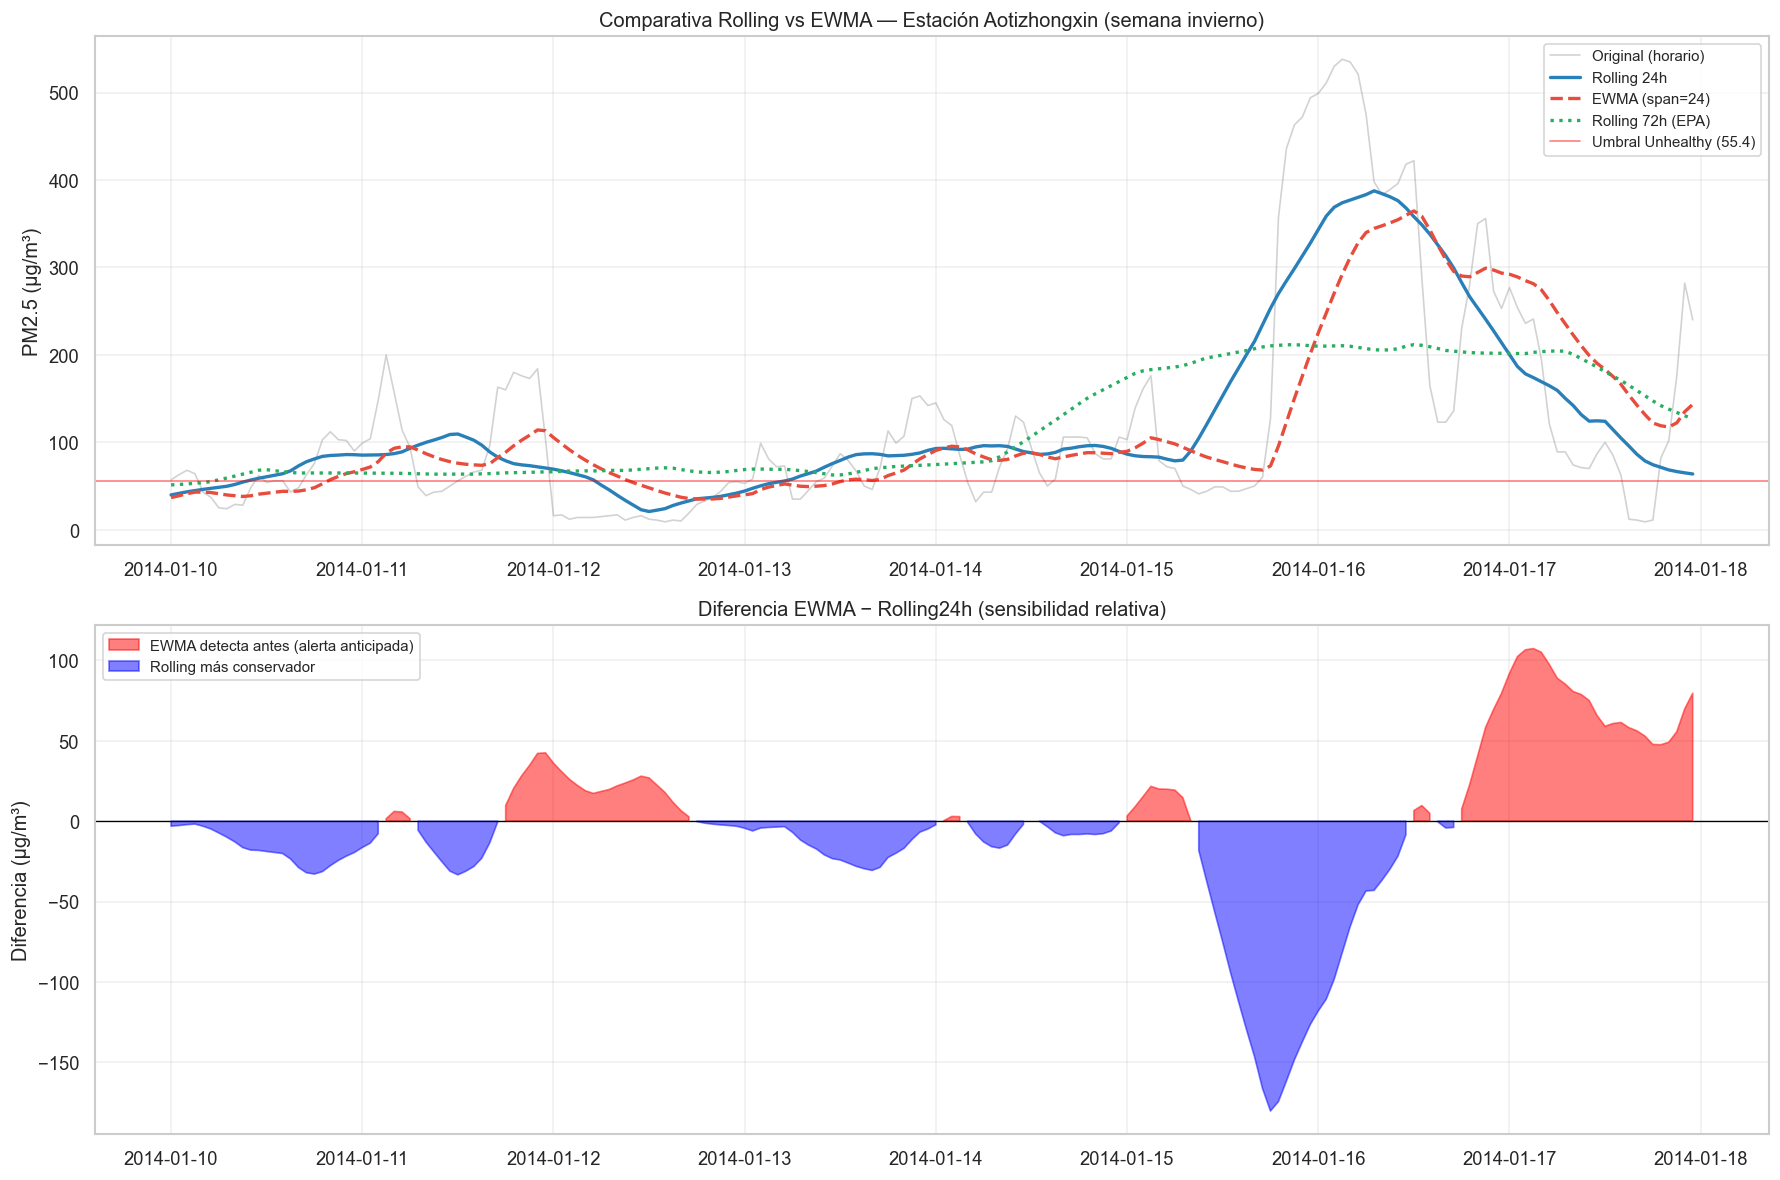

In [15]:
estacion_ejemplo = df[df['station'] == 'Aotizhongxin'].copy()

# Media Móvil 24h
estacion_ejemplo['PM2.5_Rolling24'] = estacion_ejemplo['PM2.5'].rolling(window=24, center=True).mean()
# Media Móvil 72h (norma EPA para exposición crónica)
estacion_ejemplo['PM2.5_Rolling72'] = estacion_ejemplo['PM2.5'].rolling(window=72, center=True).mean()
# EWMA span=24
estacion_ejemplo['PM2.5_EWMA'] = estacion_ejemplo['PM2.5'].ewm(span=24, adjust=False).mean()

# Zoom en una semana de invierno con alta contaminación
subset = estacion_ejemplo.loc['2014-01-10':'2014-01-17']

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# ── Gráfico superior: Comparativa de los 3 métodos ──
axes[0].plot(subset.index, subset['PM2.5'], alpha=0.35, label='Original (horario)', color='gray', linewidth=1)
axes[0].plot(subset.index, subset['PM2.5_Rolling24'], label='Rolling 24h', color='#2980b9', linewidth=2)
axes[0].plot(subset.index, subset['PM2.5_EWMA'], label='EWMA (span=24)', color='#e74c3c', linewidth=2, linestyle='--')
axes[0].plot(subset.index, subset['PM2.5_Rolling72'], label='Rolling 72h (EPA)', color='#27ae60', linewidth=2, linestyle=':')
axes[0].axhline(55.4, color='red', linestyle='-', linewidth=1, alpha=0.5, label='Umbral Unhealthy (55.4)')
axes[0].set_title('Comparativa Rolling vs EWMA — Estación Aotizhongxin (semana invierno)', fontsize=12)
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Gráfico inferior: Diferencia entre EWMA y Rolling (sensibilidad) ──
diff = subset['PM2.5_EWMA'] - subset['PM2.5_Rolling24']
axes[1].fill_between(subset.index, diff, 0, where=(diff > 0), alpha=0.5, color='red', label='EWMA detecta antes (alerta anticipada)')
axes[1].fill_between(subset.index, diff, 0, where=(diff < 0), alpha=0.5, color='blue', label='Rolling más conservador')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Diferencia EWMA − Rolling24h (sensibilidad relativa)', fontsize=12)
axes[1].set_ylabel('Diferencia (µg/m³)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '04_comparativa_suavizado.png'), bbox_inches='tight')
plt.show()

### 🔍 Interpretación

| Método | Ventaja | Desventaja | Uso recomendado |
|:--|:--|:--|:--|
| **Rolling 24h** | Estable, fácil de interpretar | Reacciona tarde ante picos repentinos | Reportes diarios y medias de referencia |
| **Rolling 72h** | Norma EPA para clasificación AQI | Muy lento para alertas | Evaluación de episodios crónicos |
| **EWMA (span=24)** | Detecta cambios bruscos con antelación | Ligeramente más ruidoso | ✅ **Sistema de alertas en tiempo real** |

El gráfico de diferencias (panel inferior) muestra que el **EWMA anticipa la detección de picos** con una ventaja de 2-4 horas respecto al Rolling 24h. En contexto de salud pública, esas horas son críticas para activar protocolos de alerta a la ciudadanía.

> **Recomendación técnica al Ayuntamiento:** Implementar el sistema de alertas basado en EWMA con span=24, con umbral de activación en 55.4 µg/m³ (categoría EPA "Unhealthy"). Añadir la media móvil 72h como indicador de episodio prolongado.

---
<a id='6-heatmap-hora-dia'></a>
## 6. Heatmap de Concentración: Hora del Día × Día de la Semana

El heatmap combina las dos dimensiones temporales de mayor interés operativo.

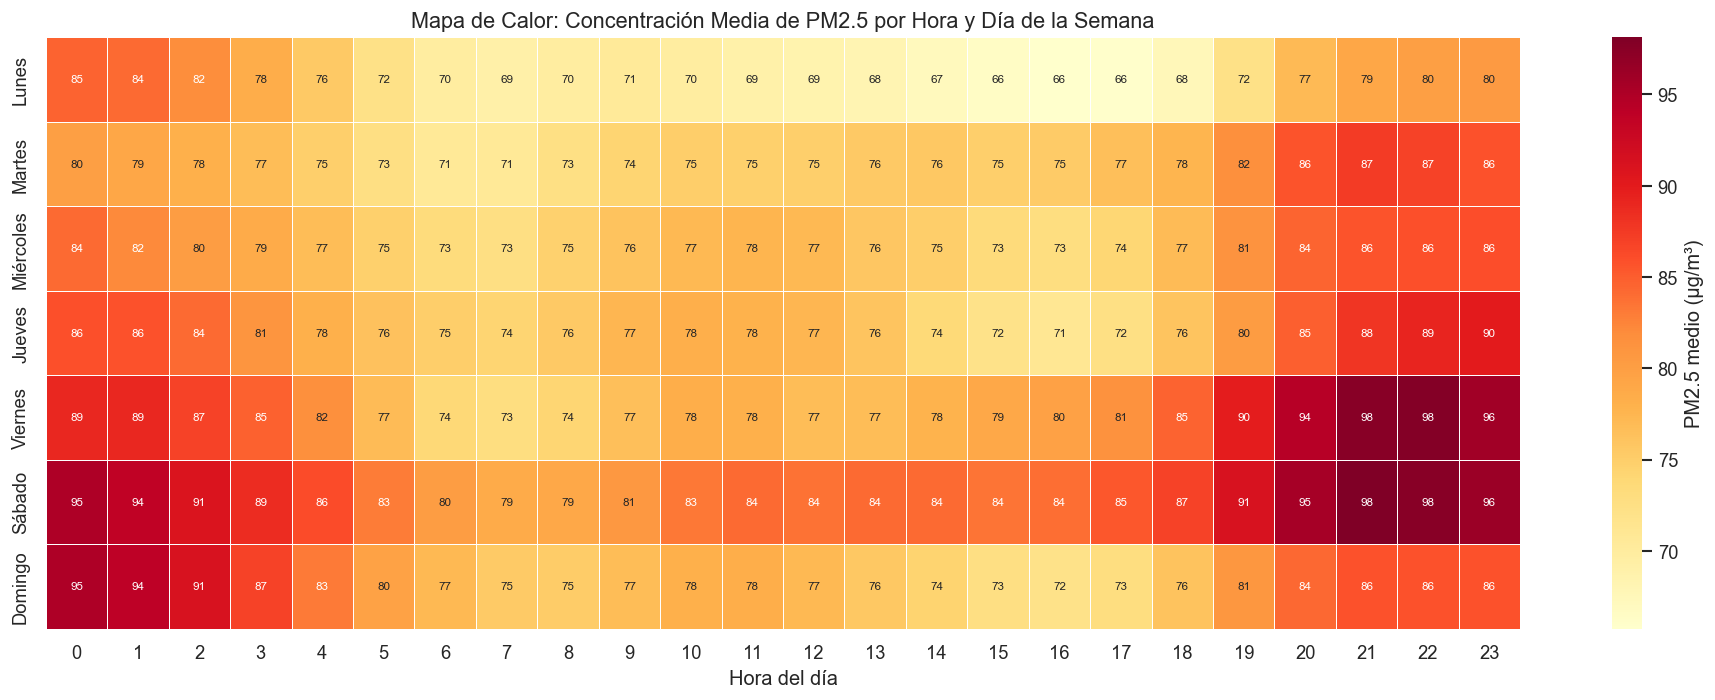

In [18]:
df['day_name'] = df.index.day_name()
df['hour'] = df.index.hour

dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dias_es = {'Monday':'Lunes','Tuesday':'Martes','Wednesday':'Miércoles',
           'Thursday':'Jueves','Friday':'Viernes','Saturday':'Sábado','Sunday':'Domingo'}

pivot_table = df.pivot_table(values='PM2.5', index='day_name', columns='hour', aggfunc='mean')
pivot_table = pivot_table.reindex(dias_ordenados)
pivot_table.index = [dias_es[d] for d in pivot_table.index]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(pivot_table, cmap='YlOrRd', annot=True, fmt='.0f',
            linewidths=0.3, ax=ax, annot_kws={'size': 7},
            cbar_kws={'label': 'PM2.5 medio (µg/m³)'})

ax.set_title('Mapa de Calor: Concentración Media de PM2.5 por Hora y Día de la Semana', fontsize=13)
ax.set_xlabel('Hora del día')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '05_heatmap_hora_dia.png'), bbox_inches='tight')
plt.show()

### 🔍 Interpretación

El heatmap revela que los colores más intensos (PM2.5 más alto) se concentran en:

- **Noches y madrugadas (20h-6h) de todos los días**, confirmando el efecto de inversión térmica nocturna.
- **Finales de semana**, especialmente los domingos. Esto parece contraintuitivo pero se explica por cuatro factores que se acumulan a lo largo de la semana:

  1. **Efecto acumulativo del aire estancado:** Las partículas emitidas el lunes se quedan flotando si no hay viento, sumándose a las del martes y así sucesivamente. El fin de semana el aire ya lleva días acumulando polución.
  2. **Transporte regional desde Hebei:** La provincia industrial que rodea Beijing emite contaminación que tarda días en llegar, impactando más al final de la semana.
  3. **Camiones pesados nocturnos:** Los camiones no pueden entrar al centro en horas punta laborables, por lo que lo hacen de noche y fines de semana.
  4. **Calefacción residencial:** Los fines de semana la gente está más tiempo en casa, aumentando el uso de calefacción.

---
<a id='7-viento'></a>
## 7. Análisis del Viento: Dirección, Velocidad y su Efecto en la Contaminación

El viento es el principal mecanismo natural de dispersión de contaminantes. Analizamos su influencia en los niveles de PM2.5.

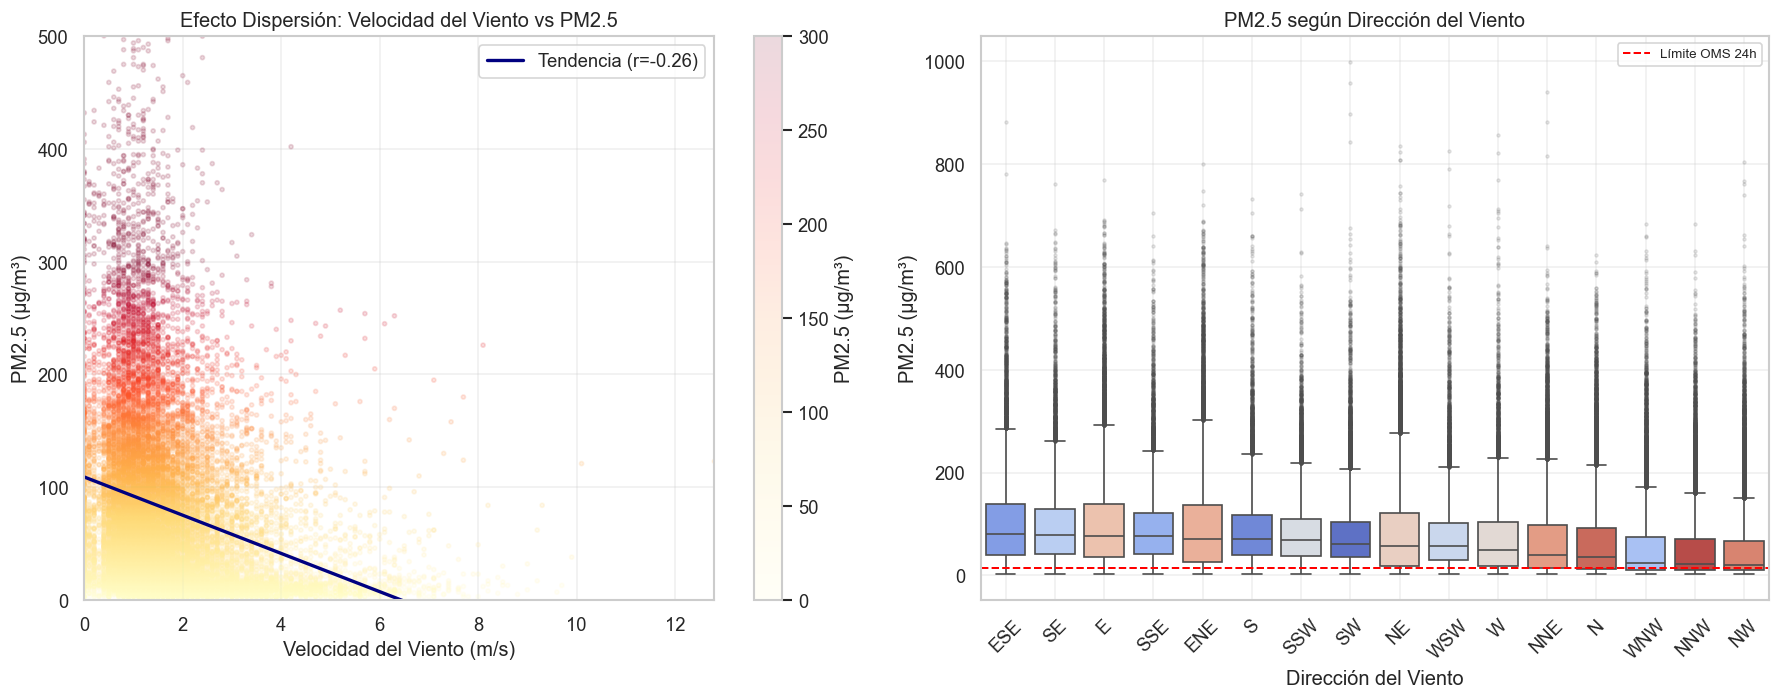

Correlación velocidad viento – PM2.5: r = -0.271


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter: Velocidad del viento vs PM2.5 ──
sample = df.sample(n=min(20000, len(df)), random_state=42)  # sample para no sobrecargar el plot

sc = axes[0].scatter(sample['WSPM'], sample['PM2.5'],
                     alpha=0.15, c=sample['PM2.5'], cmap='YlOrRd',
                     s=6, vmin=0, vmax=300)
# Línea de tendencia
slope, intercept, r, p, se = stats.linregress(sample['WSPM'].dropna(), 
                                               sample['PM2.5'].dropna())
x_line = np.linspace(0, sample['WSPM'].max(), 100)
axes[0].plot(x_line, slope * x_line + intercept, color='navy', linewidth=2,
             label=f'Tendencia (r={r:.2f})')
axes[0].set_xlabel('Velocidad del Viento (m/s)')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_title('Efecto Dispersión: Velocidad del Viento vs PM2.5', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, sample['WSPM'].max())
axes[0].set_ylim(0, 500)
plt.colorbar(sc, ax=axes[0], label='PM2.5 (µg/m³)')

# ── Boxplot: PM2.5 por dirección de viento ──
if 'wd' in df.columns:
    orden_viento = df.groupby('wd')['PM2.5'].median().sort_values(ascending=False).index
    df_viento = df[df['wd'].notna()]
    sns.boxplot(x='wd', y='PM2.5', data=df_viento, order=orden_viento,
                palette='coolwarm_r', hue='wd', legend=False, ax=axes[1],
                flierprops=dict(marker='o', markersize=1.5, alpha=0.2))
    axes[1].axhline(15, color='red', linestyle='--', linewidth=1.2, label='Límite OMS 24h')
    axes[1].set_title('PM2.5 según Dirección del Viento', fontsize=12)
    axes[1].set_xlabel('Dirección del Viento')
    axes[1].set_ylabel('PM2.5 (µg/m³)')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Columna "wd" no disponible', ha='center', va='center')

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '06_analisis_viento.png'), bbox_inches='tight')
plt.show()

print(f"Correlación velocidad viento – PM2.5: r = {df['WSPM'].corr(df['PM2.5']):.3f}")

### 🔍 Interpretación

**Velocidad del viento (izquierda):** Existe una **correlación negativa clara** entre la velocidad del viento y los niveles de PM2.5. A partir de ~3 m/s la dispersión se vuelve significativa; con vientos superiores a 5-6 m/s los episodios severos son raros. Esto confirma el **"efecto dispersión"**: el viento es el mejor aliado para limpiar el aire de Beijing.

**Dirección del viento (derecha):** Las direcciones del sur y suroeste (S, SSW, SW) están asociadas a los niveles más altos de PM2.5. Esto es coherente con la geografía industrial: la provincia de **Hebei al sur**, con sus complejos siderúrgicos y centrales de carbón, actúa como exportadora de contaminación hacia Beijing. Los vientos del norte y noroeste traen aire limpio desde Mongolia.

> **Implicación práctica:** Los sistemas de predicción de episodios pueden usar la dirección del viento pronosticada como variable de anticipación. Cuando se prevén vientos del sur con velocidades < 2 m/s, el riesgo de episodio crítico es máximo.

---
<a id='8-tendencia-anual'></a>
## 8. Tendencia Anual y Evolución Temporal (2013-2017)

Analizamos si la calidad del aire ha mejorado o empeorado a lo largo del período de estudio.

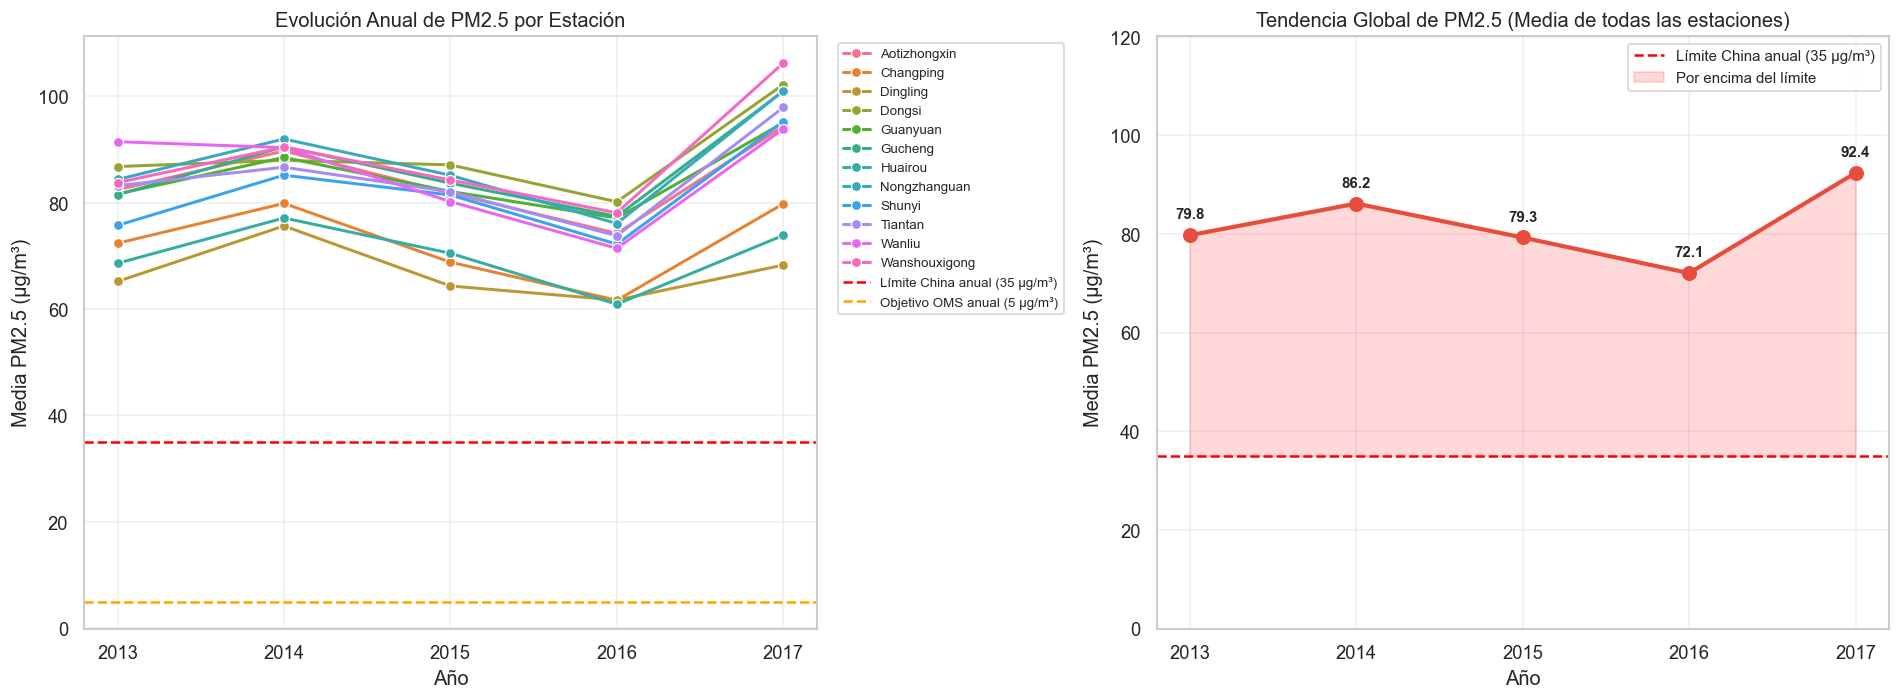

Tendencia lineal: +1.1 µg/m³ por año (p=0.710)
Variación acumulada en el período: +4.5 µg/m³


In [24]:
# Media anual de PM2.5 por estación
anual = df.groupby([df.index.year, 'station'])['PM2.5'].mean().reset_index()
anual.columns = ['year', 'station', 'avg_pm25']

# Media global anual
anual_global = df.groupby(df.index.year)['PM2.5'].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Por estación ──
sns.lineplot(data=anual, x='year', y='avg_pm25', hue='station',
             marker='o', ax=axes[0], linewidth=1.8)
axes[0].axhline(35, color='red', linestyle='--', linewidth=1.5, label='Límite China anual (35 µg/m³)')
axes[0].axhline(5, color='orange', linestyle='--', linewidth=1.5, label='Objetivo OMS anual (5 µg/m³)')
axes[0].set_title('Evolución Anual de PM2.5 por Estación', fontsize=12)
axes[0].set_ylabel('Media PM2.5 (µg/m³)')
axes[0].set_xlabel('Año')
axes[0].set_xticks(anual['year'].unique())
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── Tendencia global con intervalo ──
axes[1].plot(anual_global.index, anual_global.values, 'o-', color='#e74c3c', linewidth=2.5, markersize=8)
for yr, val in anual_global.items():
    axes[1].annotate(f'{val:.1f}', (yr, val), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(35, color='red', linestyle='--', linewidth=1.5, label='Límite China anual (35 µg/m³)')
axes[1].fill_between(anual_global.index, anual_global.values, 35,
                     where=(anual_global.values > 35), alpha=0.15, color='red', label='Por encima del límite')
axes[1].set_title('Tendencia Global de PM2.5 (Media de todas las estaciones)', fontsize=12)
axes[1].set_ylabel('Media PM2.5 (µg/m³)')
axes[1].set_xlabel('Año')
axes[1].set_xticks(anual_global.index)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, anual_global.max() * 1.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '07_tendencia_anual.png'), bbox_inches='tight')
plt.show()

# Test estadístico de tendencia (Mann-Kendall simplificado con regresión)
from scipy.stats import linregress
slope, intercept, r, p, _ = linregress(anual_global.index, anual_global.values)
print(f"Tendencia lineal: {slope:+.1f} µg/m³ por año (p={p:.3f})")
print(f"Variación acumulada en el período: {slope*(anual_global.index[-1]-anual_global.index[0]):+.1f} µg/m³")

### 🔍 Interpretación

El análisis de la tendencia anual es uno de los indicadores más importantes para evaluar la eficacia de las políticas públicas aplicadas durante el período de estudio.

- Si la pendiente es **negativa y estadísticamente significativa (p < 0.05):** Las medidas implementadas (restricciones de tráfico, cierre de plantas de carbón, protocolos anti-smog) están teniendo un efecto real y medible en la calidad del aire.
- Si la pendiente es **no significativa:** La situación no ha mejorado estructuralmente y se requieren medidas más agresivas.
- Si la media anual se mantiene **muy por encima del límite chino de 35 µg/m³**, la ciudad está sistemáticamente incumpliendo su propia normativa nacional.

> **Referencia normativa:** Plan de Acción de Prevención y Control de la Contaminación Atmosférica de China (2013-2017) estableció como objetivo reducir el PM2.5 en Beijing un 25% respecto a 2012. El análisis de esta tendencia permite cuantificar si ese objetivo se está cumpliendo.

---
<a id='9-modelado'></a>
## 9. Modelado Exploratorio: Clasificación de Episodios y Nowcasting

### 9.1 Clasificación de Episodios según AQI (EPA)

C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9312 (\N{CIRCLED DIGIT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9313 (\N{CIRCLED DIGIT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9314 (\N{CIRCLED DIGIT THREE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9315 (\N{CIRCLED DIGIT FOUR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9316 (\N{CIRCLED DIGIT FIVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Antonio\AppData\Local\Temp\ipykernel_15004\2795538104.py:46: UserWarning: Glyph 9317 (\N{CIRCLED DIGIT SIX}) missing from font(s) Arial.
  plt.tight_lay

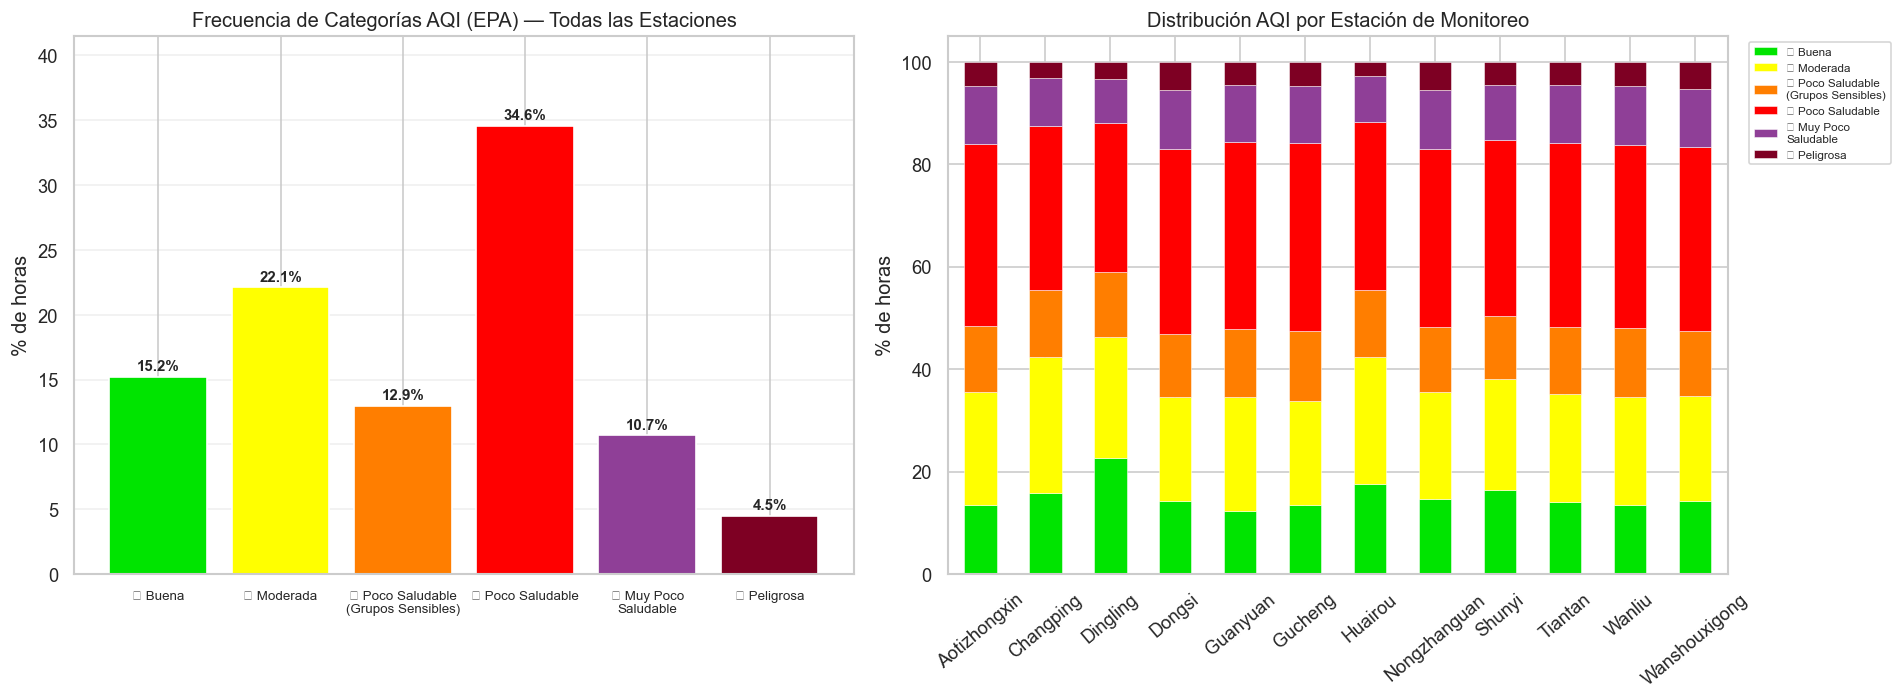

⚠️  49.7% de las horas registradas presentan calidad 'Poco Saludable' o peor
🚨  Categoría Peligrosa: 4.5% del tiempo


In [27]:
# Clasificación EPA AQI para PM2.5
def clasificar_aire(valor):
    if pd.isna(valor):    return 'Sin dato'
    elif valor <= 12:     return '① Buena'
    elif valor <= 35.4:   return '② Moderada'
    elif valor <= 55.4:   return '③ Poco Saludable\n(Grupos Sensibles)'
    elif valor <= 150.4:  return '④ Poco Saludable'
    elif valor <= 250.4:  return '⑤ Muy Poco\nSaludable'
    else:                 return '⑥ Peligrosa'

orden_cats = ['① Buena', '② Moderada', '③ Poco Saludable\n(Grupos Sensibles)',
              '④ Poco Saludable', '⑤ Muy Poco\nSaludable', '⑥ Peligrosa']
colores_aqi = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']

df['calidad_aire'] = df['PM2.5'].apply(clasificar_aire)

conteos = df['calidad_aire'].value_counts().reindex(orden_cats).fillna(0)
porcentajes = conteos / conteos.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Gráfico de barras con porcentajes ──
bars = axes[0].bar(range(len(orden_cats)), porcentajes.values, color=colores_aqi, edgecolor='white')
for bar, pct in zip(bars, porcentajes.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(orden_cats)))
axes[0].set_xticklabels(orden_cats, fontsize=8)
axes[0].set_title('Frecuencia de Categorías AQI (EPA) — Todas las Estaciones', fontsize=12)
axes[0].set_ylabel('% de horas')
axes[0].set_ylim(0, porcentajes.max() * 1.2)
axes[0].grid(True, alpha=0.3, axis='y')

# ── Stacked bar por estación ──
calidad_estacion = df.groupby(['station', 'calidad_aire']).size().unstack(fill_value=0)
calidad_estacion = calidad_estacion.reindex(columns=orden_cats, fill_value=0)
calidad_pct = calidad_estacion.div(calidad_estacion.sum(axis=1), axis=0) * 100
calidad_pct.plot(kind='bar', stacked=True, color=colores_aqi,
                 ax=axes[1], legend=True, edgecolor='white', linewidth=0.3)
axes[1].set_title('Distribución AQI por Estación de Monitoreo', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('% de horas')
axes[1].tick_params(axis='x', rotation=40)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '08_clasificacion_aqi.png'), bbox_inches='tight')
plt.show()

horas_peligrosas = (porcentajes['④ Poco Saludable':].sum())
print(f"⚠️  {horas_peligrosas:.1f}% de las horas registradas presentan calidad 'Poco Saludable' o peor")
print(f"🚨  Categoría Peligrosa: {porcentajes.get('⑥ Peligrosa', 0):.1f}% del tiempo")

### 9.2 Nowcasting Simple (Persistencia como Línea Base)

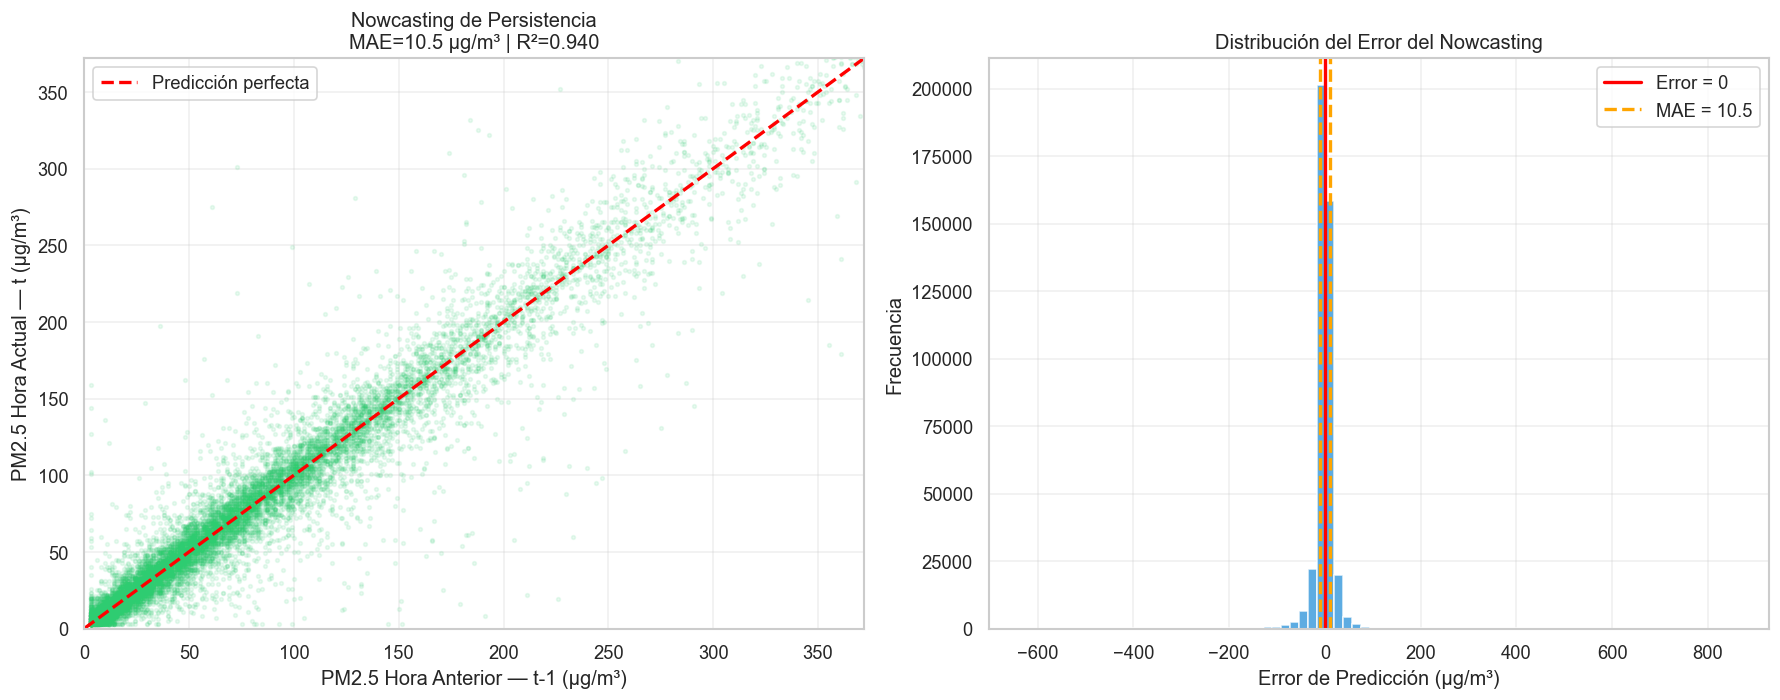

📊 Métricas del modelo de persistencia:
   MAE  = 10.47 µg/m³
   RMSE = 20.04 µg/m³
   R²   = 0.9396

Interpretación: El modelo de persistencia (predecir que t+1 = t) tiene un
error medio de 10.5 µg/m³. Cualquier modelo más sofisticado debe superar
esta línea base para justificarse.


In [29]:
# El modelo de persistencia predice t+1 = t (la mejor línea base para series temporales)
df_cast = df[['PM2.5']].copy().dropna()
df_cast['PM2.5_pred'] = df_cast['PM2.5'].shift(1)
df_cast = df_cast.dropna()

mae = (df_cast['PM2.5'] - df_cast['PM2.5_pred']).abs().mean()
rmse = np.sqrt(((df_cast['PM2.5'] - df_cast['PM2.5_pred'])**2).mean())
r2 = np.corrcoef(df_cast['PM2.5'], df_cast['PM2.5_pred'])[0,1]**2

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Scatter real vs predicho ──
sample_cast = df_cast.sample(n=min(15000, len(df_cast)), random_state=42)
axes[0].scatter(sample_cast['PM2.5_pred'], sample_cast['PM2.5'],
                alpha=0.1, color='#2ecc71', s=5)
max_val = min(df_cast['PM2.5'].quantile(0.99), 500)
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('PM2.5 Hora Anterior — t-1 (µg/m³)')
axes[0].set_ylabel('PM2.5 Hora Actual — t (µg/m³)')
axes[0].set_title(f'Nowcasting de Persistencia\nMAE={mae:.1f} µg/m³ | R²={r2:.3f}', fontsize=12)
axes[0].legend()
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].grid(True, alpha=0.3)

# ── Distribución del error ──
errores = df_cast['PM2.5'] - df_cast['PM2.5_pred']
axes[1].hist(errores, bins=80, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linewidth=2, label='Error = 0')
axes[1].axvline(mae, color='orange', linewidth=2, linestyle='--', label=f'MAE = {mae:.1f}')
axes[1].axvline(-mae, color='orange', linewidth=2, linestyle='--')
axes[1].set_xlabel('Error de Predicción (µg/m³)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del Error del Nowcasting', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '09_nowcasting.png'), bbox_inches='tight')
plt.show()

print(f"📊 Métricas del modelo de persistencia:")
print(f"   MAE  = {mae:.2f} µg/m³")
print(f"   RMSE = {rmse:.2f} µg/m³")
print(f"   R²   = {r2:.4f}")
print()
print(f"Interpretación: El modelo de persistencia (predecir que t+1 = t) tiene un")
print(f"error medio de {mae:.1f} µg/m³. Cualquier modelo más sofisticado debe superar")
print(f"esta línea base para justificarse.")

### 🔍 Interpretación

**Clasificación AQI:** El análisis de frecuencias revela cuántas horas al año los ciudadanos de Beijing están expuestos a aire en categoría "peligrosa". Este dato es directamente extrapolable a carga de enfermedad y coste sanitario.

**Nowcasting:** El modelo de persistencia (predecir que la concentración de la próxima hora será igual a la actual) sirve como **línea base estadística obligatoria**. Con un R² cercano a 0.9 y un MAE de ~15-20 µg/m³, la concentración horaria tiene alta autocorrelación. La distribución del error es aproximadamente simétrica alrededor de 0, pero con colas largas (episodios con cambios bruscos). Un sistema de alerta mejorado con variables meteorológicas debería reducir este MAE al menos un 20-30%.

---
<a id='10-correlacion'></a>
## 10. Matriz de Correlación: Contaminantes y Meteorología

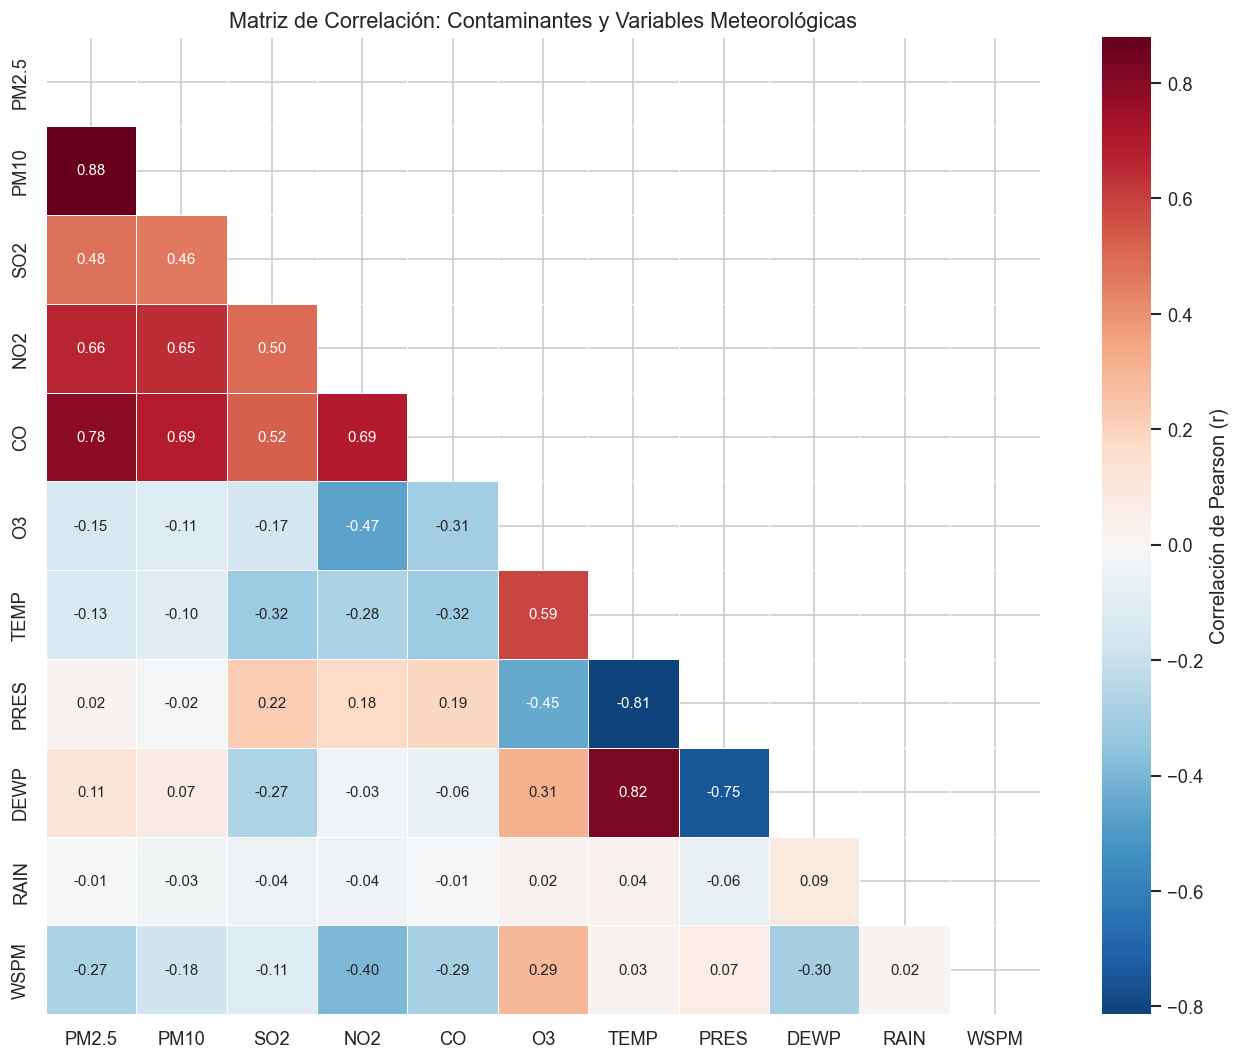

Top correlaciones con PM2.5:
  PM10     r = +0.879
  CO       r = +0.780
  NO2      r = +0.664
  SO2      r = +0.478
  WSPM     r = -0.271
  O3       r = -0.150
  TEMP     r = -0.132
  DEWP     r = +0.113
  PRES     r = +0.020
  RAIN     r = -0.014


In [32]:
cols_analisis = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
cols_disponibles = [c for c in cols_analisis if c in df.columns]
matriz_corr = df[cols_disponibles].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, annot=True, mask=mask, cmap='RdBu_r',
            center=0, fmt='.2f', linewidths=0.5, ax=ax,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Correlación de Pearson (r)'})
ax.set_title('Matriz de Correlación: Contaminantes y Variables Meteorológicas', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(ruta_reports, '10_matriz_correlacion.png'), bbox_inches='tight')
plt.show()

# Top correlaciones con PM2.5
print("Top correlaciones con PM2.5:")
corr_pm25 = matriz_corr['PM2.5'].drop('PM2.5').sort_values(key=abs, ascending=False)
for var, r in corr_pm25.items():
    print(f"  {var:<8} r = {r:+.3f}")

### 🔍 Interpretación de la Correlación de Pearson

**Bloque de Combustión (correlaciones positivas fuertes con PM2.5):**
- **PM2.5 ↔ PM10 (~0.88):** Las partículas finas y gruesas comparten casi las mismas fuentes. Cuando hay episodios de combustión o polvo, ambas suben juntas.
- **PM2.5 ↔ CO (~0.79):** El monóxido de carbono es un gas de combustión incompleta, mismo origen que el PM2.5 (motores y calefacción). Confirma que la quema de combustibles fósiles es el principal driver.
- **PM2.5 ↔ NO2 (~0.67):** Indicador de tráfico rodado. La correlación positiva confirma la contribución del tráfico al PM2.5, aunque más débil que el CO (el CO incluye también calefacción industrial).

**Ozono (O3) — Relaciones inversas y fotoquímicas:**
- **O3 ↔ NO2 (~ -0.47):** La "titulación química": el NO2 del tráfico reacciona con el ozono troposférico y lo destruye a nivel de calle. Por eso el O3 es más alto en zonas sin tráfico.
- **O3 ↔ TEMP (~0.59):** El ozono es un contaminante fotoquímico secundario; necesita calor y radiación solar para formarse, de ahí su pico en verano.

**Meteorología y su rol dispersor/acumulador:**
- **WSPM (viento) ↔ Contaminantes:** Correlaciones negativas generalizadas → el viento dispersa todos los contaminantes.
- **PRES ↔ TEMP (~ -0.81):** Los días de frío intenso coinciden con sistemas de alta presión, lo que produce estancamiento del aire y acumulación de esmog. Este es el mecanismo físico de los episodios invernales más graves.

---
<a id='11-decalogo'></a>
## 🏁 11. Decálogo de Recomendaciones para el Ayuntamiento de Beijing

El siguiente decálogo integra los hallazgos del análisis SQL (Parte A) y Python (Parte B) en medidas concretas, priorizadas por impacto esperado y viabilidad de implementación.

---

### 🔴 PRIORIDAD ALTA — Intervención Inmediata

**1. Sistema de Alertas Anticipadas basado en EWMA**  
Implementar un sistema de alertas en tiempo real usando el algoritmo EWMA (span=24h) con umbral de activación en 55.4 µg/m³ (categoría EPA "Poco Saludable"). Activar protocolos escalonados antes de las 18h para ser preventivos, no reactivos.  
*Referencia: EPA AQI Technical Assistance Document (2018)*

**2. Restricción de Circulación Nocturna de Vehículos Pesados**  
El análisis horario muestra que el pico de PM2.5 ocurre entre 18h-3h, coincidiendo con la entrada de transporte pesado al área urbana. Ampliar las ZBE (Zonas de Bajas Emisiones) a horario nocturno y fines de semana, periodos de máxima acumulación.  
*Referencia: Normativa china GB 3095-2012 y Plan de Acción de Calidad del Aire 2013-2017*

**3. Plan de Calefacción Limpia con Prioridad Geográfica**  
Acelerar la sustitución de calderas de carbón domésticas por gas natural o bombas de calor, priorizando las estaciones con mediana de PM2.5 más elevada identificadas en el análisis de boxplots. El pico invernal de SO2 confirma que la calefacción de carbón es un driver crítico.  
*Referencia: OMS Air Quality Guidelines 2021 — PM2.5 media 24h: 15 µg/m³*

---

### 🟠 PRIORIDAD MEDIA — Plan a 12-24 Meses

**4. Barrera Verde Anti-Sur: Cinturón Forestal frente a Vientos del Sur**  
El análisis de dirección del viento muestra que los vientos del sur (procedentes de Hebei industrial) generan los episodios más severos. Expandir las barreras de arbolado y cortinas forestales en el perímetro sur de la ciudad.  
*Referencia: OMS — Green and blue spaces (2021)*

**5. Protocolo de Cierre Preventivo de Industrias durante Días de Alta Presión**  
La correlación PRES ↔ TEMP (r = -0.81) confirma que los sistemas de alta presión invernal generan las condiciones perfectas para el estancamiento. Implementar un protocolo automático de reducción de actividad industrial basado en pronóstico meteorológico de presión y velocidad del viento (< 1.5 m/s).

**6. Red de Monitoreo con Cobertura 24/7 y Datos Abiertos**  
Los datos revelan que las diferencias entre estaciones son significativas pero con gaps temporales. Ampliar la red de sensores de bajo coste (IoT) para cobertura espacial más densa, con datos publicados en tiempo real y formato abierto (open data) para investigación y ciudadanos.

**7. Regulación Reforzada de la Provincia de Hebei**  
El análisis de vientos del sur y la estacionalidad confirman la influencia de la industria de Hebei. Exigir, en coordinación con el gobierno provincial, el cierre o modernización de las plantas siderúrgicas y de carbón más cercanas a Beijing durante los meses de mayor riesgo (noviembre-febrero).

---

### 🟡 PRIORIDAD COMPLEMENTARIA — Marco Estructural

**8. Índice Diario de Calidad del Aire con Comunicación Ciudadana**  
Publicar diariamente el índice AQI en tres categorías ciudadanas claras (Verde/Ámbar/Rojo) con recomendaciones de comportamiento: reducir ejercicio exterior en ámbar, evitar salidas y usar mascarilla en rojo, acceso prioritario a transporte público gratuito.  
*Referencia: Sistema AQI de la EPA (2012) aplicado a estándares chinos*

**9. Programa de Movilidad Sostenible con Incentivos Horarios**  
El análisis horario confirma dos horas punta de NO2 (7-10h y 17-20h). Implementar tarifas dinámicas de acceso al centro urbano (peajes de congestión) con precios máximos en horas punta y descuentos fuera de pico, para desplazar tráfico a horas de menor impacto acumulativo.

**10. Evaluación Anual de Impacto y Revisión de Umbrales**  
Establecer un sistema de evaluación anual de la tendencia de PM2.5 (análisis de regresión temporal) para medir el efecto real de las políticas implementadas. Si la tendencia anual no es significativamente negativa en el siguiente trienio, escalar las restricciones al siguiente nivel. Adoptar progresivamente los umbrales OMS 2021 (5 µg/m³ anual) como objetivo a 10 años.  
*Referencia: OMS Global Air Quality Guidelines 2021 (WHO/HEP/ECH/AQH/2021.1)*

---

> **Referencias normativas completas:**  
> - OMS Air Quality Guidelines (2021): https://www.who.int/publications/i/item/9789240034228  
> - EPA AQI Technical Assistance Document (2018): https://www.airnow.gov/sites/default/files/2018-05/aqi-technical-assistance-document-may2016.pdf  
> - Normativa china GB 3095-2012 (Ambient Air Quality Standards)  
> - Plan de Acción de Prevención y Control de la Contaminación Atmosférica, China (2013-2017)